# 이벤트 기반 주식 가격 예측 시스템
## 지정학적 이벤트와 원자재 가격 연관성 분석

**목표**: 글로벌 뉴스 이벤트를 분석하여 원자재 가격 변동을 예측하고, 그에 따른 주식 상승 확률을 계산

**기준 날짜**: 2026년 3월 9일

# 1. 필수 라이브러리 설치 및 임포트

In [1]:
import os
os.environ["GNEWS_API_KEY"] = "실제키"
import re
import json
import warnings
from pathlib import Path
from datetime import datetime, timedelta, timezone

import numpy as np
import pandas as pd
import requests
import yfinance as yf
import hashlib

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

warnings.filterwarnings("ignore")
rcParams["font.family"] = "DejaVu Sans"
sns.set_style("whitegrid")

print("Imports loaded")

import os
os.environ["GNEWS_API_KEY"] = "5e1fe7d73352a1c85b26aa564c6d8d52"
print("LEN:", len(os.getenv("GNEWS_API_KEY")))
print("PREFIX:", os.getenv("GNEWS_API_KEY")[:6])


Imports loaded
LEN: 32
PREFIX: 5e1fe7


# 2. API 설정 및 글로벌 이벤트 데이터 수집

## API 키 설정 (무료 대안 사용)
- NewsAPI: 뉴스 데이터 수집
- yfinance: 주식 및 원자재 가격 데이터
- Alpha Vantage: 추가 시장 데이터

In [ ]:
ANALYSIS_DATE = datetime.now(timezone.utc).replace(hour=0, minute=0, second=0, microsecond=0)
LOOKBACK_DAYS = 730
FORECAST_HORIZON = 5
MIN_TRAIN_ROWS = 120

# 저장 루트
DATA_DIR = Path("Stock_analysis/data/event_driven_stock_predictor")
DATA_DIR.mkdir(parents=True, exist_ok=True)

NEWS_SNAPSHOT_DIR = DATA_DIR / "news_snapshots"
PRICE_SNAPSHOT_DIR = DATA_DIR / "price_snapshots"
NEWS_SNAPSHOT_DIR.mkdir(parents=True, exist_ok=True)
PRICE_SNAPSHOT_DIR.mkdir(parents=True, exist_ok=True)

RUN_TS = datetime.now(timezone.utc)

def _latest_snapshot_path(snapshot_dir: Path, prefix: str):
    files = sorted(snapshot_dir.glob(f"{prefix}_*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
    return files[0] if files else None

def _df_hash(df: pd.DataFrame) -> str:
    if df is None:
        return ""
    d = df.copy()
    d = d.reindex(sorted(d.columns), axis=1)
    payload = d.to_csv(index=False).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()

def save_snapshot_if_changed(df: pd.DataFrame, snapshot_dir: Path, prefix: str, run_ts: datetime):
    latest = _latest_snapshot_path(snapshot_dir, prefix)

    # 빈 데이터면 새 파일 생성 안 함
    if df is None or len(df) == 0:
        return latest, False

    if latest is not None:
        try:
            old_df = pd.read_csv(latest)
            if _df_hash(old_df) == _df_hash(df):
                return latest, False
        except Exception:
            pass

    out_path = snapshot_dir / f"{prefix}_{run_ts:%Y%m%d_%H%M%S}.csv"
    df.to_csv(out_path, index=False, encoding="utf-8")
    return out_path, True

def load_latest_snapshot_df(snapshot_dir: Path, prefix: str, empty_columns=None):
    latest = _latest_snapshot_path(snapshot_dir, prefix)
    if latest is None:
        return pd.DataFrame(columns=empty_columns or [])
    return pd.read_csv(latest)

COMMODITIES = {
    "Gold": "GC=F",
    "Silver": "SI=F",
    "Copper": "HG=F",
    "Oil_WTI": "CL=F",
    "Oil_Brent": "BZ=F",
    "Natural_Gas": "NG=F",
}

STOCKS = {
    "Market_Index": ["SPY", "QQQ", "DIA", "IWM"],
    "Sector_ETF": ["XLE", "XLF", "XLK", "XLI", "XLB", "XLP", "XLV", "XLU", "XLY", "XLRE", "XLC"],
    "Rates_Credit": ["TLT", "IEF", "SHY", "LQD", "HYG"],
    "FX_Vol": ["UUP", "VIXY"],
    "Commodity_ETF": ["GLD", "SLV", "GDX", "USO", "UNG", "DBC"],
    "Semiconductors_AI": ["NVDA", "AMD", "TSM", "AVGO", "ASML", "SMH", "SOXX"],
    "Energy_Producers": ["XOM", "CVX", "COP", "BP"],
    "Materials_Mining": ["FCX", "VALE", "RIO", "BHP"],
}

EVENT_TOPICS = {
    "Geopolitical": ["war", "conflict", "military", "sanctions", "embargo", "blockade", "middle east", "ukraine", "iran"],
    "Macro": ["inflation", "cpi", "interest rate", "fed", "recession", "gdp", "unemployment", "bond yield"],
    "Supply_Chain_Commodity": ["supply chain", "opec", "oil production", "lng", "natural gas", "copper", "shipping", "container rates"],
    "Tech_Regulation": ["semiconductor", "chip", "export control", "ai regulation", "antitrust", "data center", "taiwan", "china"],
    "Financial_Stress": ["bank stress", "credit spread", "default", "liquidity", "debt ceiling", "downgrade"],
}
EVENT_KEYWORDS = sorted({kw for kws in EVENT_TOPICS.values() for kw in kws})

POSITIVE_RISK_WORDS = [
    "war", "conflict", "crisis", "attack", "explosion", "sanctions", "embargo", "blockade",
    "disruption", "shortage", "recession", "default", "bank stress", "liquidity", "downgrade",
]

print(f"Analysis date: {ANALYSIS_DATE:%Y-%m-%d}")
print(f"Lookback days: {LOOKBACK_DAYS}")
print(f"Commodities: {len(COMMODITIES)}")
print(f"Stock categories: {len(STOCKS)}, symbols: {sum(len(v) for v in STOCKS.values())}")
print(f"Event topics: {len(EVENT_TOPICS)}, query keywords: {len(EVENT_KEYWORDS)}")
print(f"Data dir: {DATA_DIR.resolve()}")


Analysis date: 2026-03-10
Lookback days: 730
Commodities: 6
Stock categories: 8, symbols: 43
Event topics: 5, query keywords: 39
Data dir: C:\Users\user\Documents\GitHub\GB_practicing\data\event_driven_stock_predictor


# 3. 글로벌 뉴스 및 이벤트 데이터 수집

In [ ]:
def _safe_text(value):
    return str(value) if value is not None else ""

def _risk_score_from_text(title, description):
    text = f"{_safe_text(title)} {_safe_text(description)}".lower()
    hits = sum(1 for w in POSITIVE_RISK_WORDS if w in text)
    return min(hits / max(len(POSITIVE_RISK_WORDS), 1), 1.0)

def fetch_news_from_api(keywords, from_dt, to_dt):
    gnews_key = os.getenv("GNEWS_API_KEY", "").strip()
    newsapi_key = os.getenv("NEWSAPI_KEY", "").strip()
    all_rows = []

    print(f"API key status -> GNEWS: {bool(gnews_key)} (len={len(gnews_key)}), NEWSAPI: {bool(newsapi_key)} (len={len(newsapi_key)})")

    if not gnews_key and not newsapi_key:
        print("No GNEWS_API_KEY or NEWSAPI_KEY found. API collection skipped.")
        return pd.DataFrame(columns=["date", "keyword", "title", "description", "source", "url", "risk_score"])

    def query_gnews(keyword):
        if not gnews_key:
            return []
        url = "https://gnews.io/api/v4/search"
        params = {
            "q": keyword,
            "lang": "en",
            "from": from_dt.strftime("%Y-%m-%dT%H:%M:%SZ"),
            "to": to_dt.strftime("%Y-%m-%dT%H:%M:%SZ"),
            "sortby": "publishedAt",
            "max": 100,
            "apikey": gnews_key,
        }
        try:
            r = requests.get(url, params=params, timeout=15)
            if r.status_code == 200:
                return r.json().get("articles", [])
            if r.status_code in (401, 403):
                print(f"GNews auth error: {r.status_code} (keyword={keyword})")
            elif r.status_code == 429:
                print(f"GNews rate limit: {r.status_code} (keyword={keyword})")
        except Exception as e:
            print(f"GNews request error (keyword={keyword}): {e}")
        return []

    def query_newsapi(keyword):
        if not newsapi_key:
            return []
        url = "https://newsapi.org/v2/everything"
        params = {
            "q": keyword,
            "language": "en",
            "from": from_dt.strftime("%Y-%m-%d"),
            "to": to_dt.strftime("%Y-%m-%d"),
            "sortBy": "publishedAt",
            "pageSize": 100,
            "apiKey": newsapi_key,
        }
        try:
            r = requests.get(url, params=params, timeout=15)
            if r.status_code == 200:
                return r.json().get("articles", [])
            if r.status_code in (401, 403):
                print(f"NewsAPI auth error: {r.status_code} (keyword={keyword})")
            elif r.status_code == 429:
                print(f"NewsAPI rate limit: {r.status_code} (keyword={keyword})")
        except Exception as e:
            print(f"NewsAPI request error (keyword={keyword}): {e}")
        return []

    for kw in keywords:
        articles = query_gnews(kw)
        if not articles:
            articles = query_newsapi(kw)

        for a in articles:
            date_raw = a.get("publishedAt") or a.get("published_at")
            if not date_raw:
                continue
            try:
                dt = pd.to_datetime(date_raw, utc=True)
            except Exception:
                continue

            title = _safe_text(a.get("title"))
            desc = _safe_text(a.get("description"))
            src = a.get("source", "Unknown")
            if isinstance(src, dict):
                src = _safe_text(src.get("name"))

            all_rows.append(
                {
                    "date": dt,
                    "keyword": kw,
                    "title": title,
                    "description": desc,
                    "source": src,
                    "url": _safe_text(a.get("url")),
                    "risk_score": _risk_score_from_text(title, desc),
                }
            )

    if not all_rows:
        return pd.DataFrame(columns=["date", "keyword", "title", "description", "source", "url", "risk_score"])

    df = pd.DataFrame(all_rows)
    df["date"] = pd.to_datetime(df["date"], utc=True)
    df = df.drop_duplicates(subset=["title", "source"]).sort_values("date")
    return df

def build_daily_news_features(df_news, analysis_date):
    if df_news.empty:
        idx = pd.date_range(analysis_date - timedelta(days=LOOKBACK_DAYS), analysis_date, freq="D", tz="UTC")
        return pd.DataFrame({"date": idx, "news_count": 0, "avg_risk": 0.0, "max_risk": 0.0})

    base = df_news.copy()
    base["date"] = pd.to_datetime(base["date"], utc=True).dt.floor("D")
    base["title_desc"] = (base["title"].fillna("") + " " + base["description"].fillna("")).str.lower()

    daily = base.groupby("date").agg(
        news_count=("title", "count"),
        avg_risk=("risk_score", "mean"),
        max_risk=("risk_score", "max"),
    ).reset_index()

    for kw in ["oil", "war", "sanctions", "china", "taiwan", "inflation"]:
        daily[f"kw_{kw}"] = base.groupby("date")["title_desc"].apply(lambda x, p=kw: x.str.contains(p, regex=False).sum()).values

    full_idx = pd.date_range(analysis_date - timedelta(days=LOOKBACK_DAYS), analysis_date, freq="D", tz="UTC")
    full = pd.DataFrame({"date": full_idx})
    merged = full.merge(daily, on="date", how="left").fillna(0)
    return merged

from_dt = ANALYSIS_DATE - timedelta(days=LOOKBACK_DAYS)
to_dt = ANALYSIS_DATE + timedelta(days=1)

latest_news_before = load_latest_snapshot_df(
    NEWS_SNAPSHOT_DIR, "news_history",
    empty_columns=["date","keyword","title","description","source","url","risk_score"]
)

new_news = fetch_news_from_api(EVENT_KEYWORDS, from_dt, to_dt)
print(f"Latest snapshot rows(before): {len(latest_news_before)}")
print(f"Newly fetched news rows: {len(new_news)}")

df_news = pd.concat([latest_news_before, new_news], ignore_index=True)
if not df_news.empty:
    df_news["date"] = pd.to_datetime(df_news["date"], utc=True, errors="coerce")
    df_news = df_news.dropna(subset=["date"])
    df_news = df_news.drop_duplicates(subset=["title", "source"]).sort_values("date")
    cutoff = ANALYSIS_DATE - timedelta(days=LOOKBACK_DAYS)
    df_news = df_news[df_news["date"] >= cutoff]

news_path, news_written = save_snapshot_if_changed(df_news, NEWS_SNAPSHOT_DIR, "news_history", RUN_TS)
print(f"news snapshot path: {news_path}")
print(f"news snapshot written: {news_written}")

# 항상 최신 snapshot을 다시 로드해서 downstream 일관성 유지
df_news = load_latest_snapshot_df(
    NEWS_SNAPSHOT_DIR, "news_history",
    empty_columns=["date","keyword","title","description","source","url","risk_score"]
)
if len(df_news) > 0:
    df_news["date"] = pd.to_datetime(df_news["date"], utc=True, errors="coerce")
    df_news = df_news.dropna(subset=["date"]).sort_values("date")

daily_news = build_daily_news_features(df_news, ANALYSIS_DATE)

print(f"News rows (latest snapshot): {len(df_news)}")
if len(df_news) > 0:
    print(df_news[["date", "keyword", "title", "risk_score"]].tail(5))
print(f"Daily news feature rows: {len(daily_news)}")

latest_news_file = _latest_snapshot_path(NEWS_SNAPSHOT_DIR, "news_history")
if latest_news_file and latest_news_file.exists():
    st = latest_news_file.stat()
    print(f"latest news file: {latest_news_file}")
    print(f"last_modified: {datetime.fromtimestamp(st.st_mtime)}")
    print(f"size_bytes: {st.st_size}")


API key status -> GNEWS: True (len=32), NEWSAPI: False (len=0)


# 4. 원자재 및 주식 가격 데이터 수집

In [4]:
def _flatten_close(df):
    if df is None or df.empty:
        return pd.DataFrame(columns=["date", "close", "volume"])

    x = df.copy()
    if isinstance(x.columns, pd.MultiIndex):
        x.columns = ["_".join([str(p) for p in col if p != ""]) if isinstance(col, tuple) else str(col) for col in x.columns]

    close_cols = [col for col in x.columns if str(col).lower().startswith("close")]
    volume_cols = [col for col in x.columns if str(col).lower().startswith("volume")]

    close_series = pd.to_numeric(x[close_cols[0]], errors="coerce") if close_cols else pd.Series(np.nan, index=x.index)
    volume_series = pd.to_numeric(x[volume_cols[0]], errors="coerce") if volume_cols else pd.Series(np.nan, index=x.index)

    out = pd.DataFrame({"date": x.index, "close": close_series.values, "volume": volume_series.values}).reset_index(drop=True)
    out["date"] = pd.to_datetime(out["date"], utc=True, errors="coerce")
    out["close"] = pd.to_numeric(out["close"], errors="coerce")
    out["volume"] = pd.to_numeric(out["volume"], errors="coerce")
    return out.dropna(subset=["date", "close"])

def fetch_symbol_history(symbol, start_date, end_date):
    try:
        df = yf.download(symbol, start=start_date, end=end_date, progress=False, auto_adjust=True, threads=False)
        return _flatten_close(df)
    except Exception:
        return pd.DataFrame(columns=["date", "close", "volume"])

def build_asset_map():
    rows = []
    for name, sym in COMMODITIES.items():
        rows.append({"symbol": sym, "asset_name": name, "category": "Commodity", "kind": "commodity"})
    for cat, syms in STOCKS.items():
        for s in syms:
            rows.append({"symbol": s, "asset_name": s, "category": cat, "kind": "stock"})
    return pd.DataFrame(rows)

asset_map = build_asset_map()
start_date = ANALYSIS_DATE - timedelta(days=LOOKBACK_DAYS)
end_date = ANALYSIS_DATE + timedelta(days=1)

fresh_rows = []
for _, a in asset_map.iterrows():
    raw = fetch_symbol_history(a["symbol"], start_date, end_date)
    if raw.empty:
        continue
    raw["symbol"] = a["symbol"]
    raw["asset_name"] = a["asset_name"]
    raw["category"] = a["category"]
    raw["kind"] = a["kind"]
    fresh_rows.append(raw)

fresh_prices = pd.concat(fresh_rows, ignore_index=True) if fresh_rows else pd.DataFrame(
    columns=["date", "close", "volume", "symbol", "asset_name", "category", "kind"]
)

latest_price_before = load_latest_snapshot_df(
    PRICE_SNAPSHOT_DIR, "price_history",
    empty_columns=["date","close","volume","symbol","asset_name","category","kind"]
)

df_prices = pd.concat([latest_price_before, fresh_prices], ignore_index=True)
if not df_prices.empty:
    df_prices["date"] = pd.to_datetime(df_prices["date"], utc=True, errors="coerce")
    df_prices["close"] = pd.to_numeric(df_prices["close"], errors="coerce")
    df_prices["volume"] = pd.to_numeric(df_prices["volume"], errors="coerce")
    df_prices = df_prices.dropna(subset=["date", "close"])
    df_prices = df_prices.drop_duplicates(subset=["date", "symbol"], keep="last")
    df_prices = df_prices[df_prices["date"] >= start_date]
    df_prices = df_prices.sort_values(["symbol", "date"]).reset_index(drop=True)

    def _safe_change(series, periods=1):
        s = pd.to_numeric(series, errors="coerce")
        base = s.shift(periods).replace(0, np.nan)
        return s.div(base) - 1

    g = df_prices.groupby("symbol", group_keys=False)
    df_prices["return_1d"] = g["close"].transform(lambda s: _safe_change(s, 1))
    df_prices["vol_20d"] = g["return_1d"].rolling(20).std().reset_index(level=0, drop=True)
    df_prices["mom_5d"] = g["close"].transform(lambda s: _safe_change(s, 5))
    df_prices["mom_20d"] = g["close"].transform(lambda s: _safe_change(s, 20))
    df_prices["volume_chg_5d"] = g["volume"].transform(lambda s: _safe_change(s, 5))

price_path, price_written = save_snapshot_if_changed(df_prices, PRICE_SNAPSHOT_DIR, "price_history", RUN_TS)
print(f"price snapshot path: {price_path}")
print(f"price snapshot written: {price_written}")

df_prices = load_latest_snapshot_df(PRICE_SNAPSHOT_DIR, "price_history")
if len(df_prices) > 0:
    df_prices["date"] = pd.to_datetime(df_prices["date"], utc=True, errors="coerce")
    for c in ["close","volume","return_1d","vol_20d","mom_5d","mom_20d","volume_chg_5d"]:
        if c in df_prices.columns:
            df_prices[c] = pd.to_numeric(df_prices[c], errors="coerce")

print(f"Price rows (latest snapshot): {len(df_prices)}")
print(f"Tracked symbols: {df_prices['symbol'].nunique() if len(df_prices)>0 else 0}")

if df_prices.empty:
    print("No price data available.")
else:
    latest_snapshot = (
        df_prices.sort_values("date")
        .groupby("symbol")
        .tail(1)[["symbol", "category", "close", "return_1d", "vol_20d"]]
        .sort_values("category")
    )
    print(latest_snapshot.head(15))
    print(f"Date range: {df_prices['date'].min()} -> {df_prices['date'].max()}")

latest_price_file = _latest_snapshot_path(PRICE_SNAPSHOT_DIR, "price_history")
if latest_price_file and latest_price_file.exists():
    st = latest_price_file.stat()
    print(f"latest price file: {latest_price_file}")
    print(f"last_modified: {datetime.fromtimestamp(st.st_mtime)}")
    print(f"size_bytes: {st.st_size}")


price snapshot path: data\event_driven_stock_predictor\price_snapshots\price_history_20260310_033545.csv
price snapshot written: True
Price rows (latest snapshot): 24512
Tracked symbols: 49
      symbol          category        close  return_1d   vol_20d
3503    CL=F         Commodity    89.529999  -0.015072  0.037417
8007    HG=F         Commodity     5.901500   0.025100  0.017956
13011   SI=F         Commodity    89.080002   0.062804  0.049984
6505    GC=F         Commodity  5176.000000   0.005810  0.018170
10509   NG=F         Commodity     3.123000  -0.019774  0.036151
3001    BZ=F         Commodity    93.660004   0.010465  0.028904
7505     GLD     Commodity_ETF   472.529999  -0.002070  0.020873
17011    USO     Commodity_ETF   104.330002  -0.040820  0.037461
7005     GDX     Commodity_ETF   102.440002   0.010456  0.037358
13511    SLV     Commodity_ETF    78.260002   0.030550  0.052277
5003     DBC     Commodity_ETF    27.139999  -0.013450  0.014269
16511    UNG     Commodity_ETF

# 5. 데이터 전처리 및 특성 엔지니어링

In [5]:
# 최신 snapshot 강제 재로딩 (중간 셀만 실행해도 일관성 유지)
df_news = load_latest_snapshot_df(
    NEWS_SNAPSHOT_DIR, "news_history",
    empty_columns=["date","keyword","title","description","source","url","risk_score"]
)
if len(df_news) > 0:
    df_news["date"] = pd.to_datetime(df_news["date"], utc=True, errors="coerce")
    df_news = df_news.dropna(subset=["date"]).sort_values("date")

daily_news = build_daily_news_features(df_news, ANALYSIS_DATE)

df_prices = load_latest_snapshot_df(PRICE_SNAPSHOT_DIR, "price_history")
if len(df_prices) > 0:
    df_prices["date"] = pd.to_datetime(df_prices["date"], utc=True, errors="coerce")
    for c in ["close","volume","return_1d","vol_20d","mom_5d","mom_20d","volume_chg_5d"]:
        if c in df_prices.columns:
            df_prices[c] = pd.to_numeric(df_prices[c], errors="coerce")

def compute_lead_lag(event_daily, price_daily, max_lag=7):
    if event_daily.empty or price_daily.empty:
        return pd.DataFrame(columns=["symbol", "best_lag", "best_corr"])

    e = event_daily[["date", "avg_risk"]].copy()
    e["date"] = pd.to_datetime(e["date"], utc=True).dt.tz_localize(None)

    results = []
    for sym, sdf in price_daily.groupby("symbol"):
        s = sdf[["date", "return_1d"]].dropna().copy()
        if len(s) < 30:
            continue
        s["date"] = pd.to_datetime(s["date"], utc=True).dt.tz_localize(None)
        merged = s.merge(e, on="date", how="left").fillna(0)

        best_lag = 0
        best_corr = 0.0
        for lag in range(-max_lag, max_lag + 1):
            shifted = merged["avg_risk"].shift(lag)
            corr = merged["return_1d"].corr(shifted)
            if pd.notna(corr) and abs(corr) > abs(best_corr):
                best_corr = float(corr)
                best_lag = lag
        results.append({"symbol": sym, "best_lag": best_lag, "best_corr": best_corr})

    return pd.DataFrame(results).sort_values("best_corr", key=np.abs, ascending=False)

df_lead_lag = compute_lead_lag(daily_news, df_prices, max_lag=7)
print("Lead-lag sample:")
print(df_lead_lag.head(10))

def create_model_dataset(df_prices, daily_news, horizon=5):
    if df_prices.empty:
        return pd.DataFrame()

    base = df_prices.copy()
    base["date"] = pd.to_datetime(base["date"], utc=True).dt.floor("D")
    news = daily_news.copy()
    news["date"] = pd.to_datetime(news["date"], utc=True).dt.floor("D")

    merged = base.merge(news, on="date", how="left").fillna(0)
    merged = merged.sort_values(["symbol", "date"]).reset_index(drop=True)

    g = merged.groupby("symbol", group_keys=False)
    future_close = g["close"].shift(-horizon)
    current_close = pd.to_numeric(merged["close"], errors="coerce").replace(0, np.nan)
    merged["target_return"] = future_close.div(current_close) - 1.0
    merged["target_up"] = (merged["target_return"] > 0).astype(int)
    merged["ret_lag1"] = g["return_1d"].shift(1)
    merged["ret_lag3"] = g["return_1d"].rolling(3).mean().reset_index(level=0, drop=True)
    merged["ret_lag10"] = g["return_1d"].rolling(10).mean().reset_index(level=0, drop=True)
    merged["vol_lag10"] = g["return_1d"].rolling(10).std().reset_index(level=0, drop=True)

    feature_cols = [
        "news_count", "avg_risk", "max_risk", "kw_oil", "kw_war", "kw_sanctions",
        "kw_china", "kw_taiwan", "kw_inflation",
        "return_1d", "vol_20d", "mom_5d", "mom_20d", "volume_chg_5d",
        "ret_lag1", "ret_lag3", "ret_lag10", "vol_lag10",
    ]

    for c in feature_cols:
        if c not in merged.columns:
            merged[c] = 0.0

    cols = ["date", "symbol", "asset_name", "category", "kind", "target_return", "target_up"] + feature_cols
    ds = merged[cols].dropna(subset=["target_return"]).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return ds

df_features = create_model_dataset(df_prices, daily_news, horizon=FORECAST_HORIZON)
print(f"Model dataset rows: {len(df_features)}")
print(f"Symbols in dataset: {df_features['symbol'].nunique() if len(df_features)>0 else 0}")
if len(df_features) > 0:
    print(df_features.head(3))

print("Diagnostics")
if len(df_news) == 0:
    print("- News snapshot empty. Keep collecting over time.")
else:
    print(f"- News date range: {df_news['date'].min()} -> {df_news['date'].max()}")
    print(f"- News unique sources: {df_news['source'].nunique()}")

if len(df_prices) == 0:
    print("- Price snapshot empty.")
else:
    min_rows = df_prices.groupby("symbol").size().min()
    print(f"- Price symbols: {df_prices['symbol'].nunique()}, min rows per symbol: {int(min_rows)}")


Lead-lag sample:
   symbol  best_lag  best_corr
6    CL=F         5   0.234468
5    BZ=F         2   0.229758
33    USO         6   0.195040
9     DBC         1   0.134275
40    XLF         6  -0.122629
26    SLV        -2  -0.119470
0     AMD         7   0.117939
3     BHP        -7   0.112788
35   VALE         2  -0.112409
4      BP         1   0.104826
Model dataset rows: 24267
Symbols in dataset: 49
                       date symbol asset_name           category   kind  \
0 2024-03-11 00:00:00+00:00    AMD        AMD  Semiconductors_AI  stock   
1 2024-03-12 00:00:00+00:00    AMD        AMD  Semiconductors_AI  stock   
2 2024-03-13 00:00:00+00:00    AMD        AMD  Semiconductors_AI  stock   

   target_return  target_up  news_count  avg_risk  max_risk  ...  \
0      -0.039014          0         0.0       0.0       0.0  ...   
1      -0.105248          0         0.0       0.0       0.0  ...   
2      -0.077314          0         0.0       0.0       0.0  ...   

   kw_inflation  re

# 6. 현재 이벤트 확률 분석

In [6]:
def assess_current_event_themes(df_news, analysis_date):
    themes = {
        "Energy Supply Shock": ["oil", "gas", "pipeline", "embargo", "opec"],
        "Geopolitical Conflict": ["war", "conflict", "military", "attack", "sanctions"],
        "China-Taiwan Tension": ["china", "taiwan", "strait", "semiconductor", "chip"],
        "Macro Stress": ["inflation", "interest rate", "recession", "fed", "cpi"],
    }

    if df_news.empty:
        return pd.DataFrame([{"Theme": k, "Probability": 0.1} for k in themes])

    recent_cut = analysis_date - timedelta(days=30)
    recent = df_news[pd.to_datetime(df_news["date"], utc=True) >= recent_cut].copy()
    recent["text"] = (recent["title"].fillna("") + " " + recent["description"].fillna("")).str.lower()
    if recent.empty:
        return pd.DataFrame([{"Theme": k, "Probability": 0.1} for k in themes])

    rows = []
    for theme, kws in themes.items():
        hits = 0
        for kw in kws:
            hits += recent["text"].str.contains(re.escape(kw), regex=True).sum()
        freq = min(hits / max(len(recent), 1), 1.0)
        avg_risk = recent.loc[recent["text"].str.contains("|".join(map(re.escape, kws)), regex=True), "risk_score"]
        risk = float(avg_risk.mean()) if len(avg_risk) > 0 else 0.0
        prob = float(np.clip(0.65 * risk + 0.35 * freq, 0.05, 0.95))
        rows.append({"Theme": theme, "Probability": prob})

    return pd.DataFrame(rows).sort_values("Probability", ascending=False)


df_threats = assess_current_event_themes(df_news, ANALYSIS_DATE)
print("Current issue probabilities:")
print(df_threats)


Current issue probabilities:
                   Theme  Probability
1  Geopolitical Conflict     0.250937
0    Energy Supply Shock     0.194604
3           Macro Stress     0.122896
2   China-Taiwan Tension     0.111827


# 7. 이벤트 기반 주식 가격 상승 예측

In [7]:
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from joblib import Parallel, delayed

# CPU 사용 강도 설정
# -1이면 모든 코어 사용, 너무 버벅이면 os.cpu_count()//2로 줄이세요.
N_WORKERS = -1

def _calc_confidence(cv_r2_mean, cv_mae_mean, up_acc_cv_mean):
    r2_part = max(cv_r2_mean, 0.0) * 0.45
    mae_part = (1.0 - min(cv_mae_mean / 0.06, 1.0)) * 0.35
    cls_part = up_acc_cv_mean * 0.20
    return float(np.clip(r2_part + mae_part + cls_part, 0.0, 1.0))

def _best_rf_regressor_with_tscv(X, y, random_state=42):
    # 계산량 증가(정확도+CPU 로드)
    param_grid = {
        "n_estimators": [300, 600],
        "max_depth": [None, 12, 20],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", 0.7],
    }
    tscv = TimeSeriesSplit(n_splits=5)

    best = None
    best_score = -np.inf
    for p in ParameterGrid(param_grid):
        fold_r2, fold_mae = [], []
        for tr_idx, va_idx in tscv.split(X):
            X_tr, X_va = X[tr_idx], X[va_idx]
            y_tr, y_va = y[tr_idx], y[va_idx]

            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr)
            X_va_sc = scaler.transform(X_va)

            reg = RandomForestRegressor(
                n_estimators=p["n_estimators"],
                max_depth=p["max_depth"],
                min_samples_leaf=p["min_samples_leaf"],
                max_features=p["max_features"],
                random_state=random_state,
                n_jobs=1,  # 외부 병렬과 중복 방지
            )
            reg.fit(X_tr_sc, y_tr)
            y_hat = reg.predict(X_va_sc)
            fold_r2.append(r2_score(y_va, y_hat))
            fold_mae.append(mean_absolute_error(y_va, y_hat))

        r2_mean = float(np.mean(fold_r2))
        mae_mean = float(np.mean(fold_mae))
        score = r2_mean - 0.25 * mae_mean
        if score > best_score:
            best_score = score
            best = {
                "params": p,
                "cv_r2_mean": r2_mean,
                "cv_mae_mean": mae_mean,
            }
    return best

def _cv_up_accuracy(X, y_up, random_state=42):
    tscv = TimeSeriesSplit(n_splits=5)
    fold_acc = []
    for tr_idx, va_idx in tscv.split(X):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y_up[tr_idx], y_up[va_idx]

        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_va_sc = scaler.transform(X_va)

        clf = RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=2,
            random_state=random_state,
            n_jobs=1,  # 외부 병렬과 중복 방지
        )
        clf.fit(X_tr_sc, y_tr)
        y_hat = (clf.predict_proba(X_va_sc)[:, 1] >= 0.5).astype(int)
        fold_acc.append(accuracy_score(y_va, y_hat))
    return float(np.mean(fold_acc))

def _fit_one_symbol(sym, sdf, feature_cols, threat_boost):
    sdf = sdf.sort_values("date").reset_index(drop=True)
    if len(sdf) < max(MIN_TRAIN_ROWS, 160):
        return None, None

    split = int(len(sdf) * 0.8)
    train, test = sdf.iloc[:split], sdf.iloc[split:]
    if len(test) < 30:
        return None, None

    X_train = train[feature_cols].values
    y_train = train["target_return"].values
    X_test = test[feature_cols].values
    y_test = test["target_return"].values

    best = _best_rf_regressor_with_tscv(X_train, y_train, random_state=42)
    if best is None:
        return None, None

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    reg = RandomForestRegressor(
        **best["params"],
        random_state=42,
        n_jobs=1,
    )
    reg.fit(X_train_sc, y_train)
    y_pred = reg.predict(X_test_sc)

    holdout_mae = float(mean_absolute_error(y_test, y_pred))
    holdout_r2 = float(r2_score(y_test, y_pred))

    y_train_up = (y_train > 0).astype(int)
    y_test_up = (y_test > 0).astype(int)

    clf = RandomForestClassifier(
        n_estimators=450,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=1,
    )
    clf.fit(X_train_sc, y_train_up)
    up_prob_test = clf.predict_proba(X_test_sc)[:, 1]
    holdout_up_acc = float(accuracy_score(y_test_up, (up_prob_test >= 0.5).astype(int)))

    cv_up_acc = _cv_up_accuracy(X_train, y_train_up, random_state=42)

    latest_row = sdf.iloc[-1]
    X_latest = scaler.transform(latest_row[feature_cols].values.reshape(1, -1))
    pred_return = float(reg.predict(X_latest)[0]) * threat_boost
    pred_up_prob = float(clf.predict_proba(X_latest)[0][1])

    confidence = _calc_confidence(best["cv_r2_mean"], best["cv_mae_mean"], cv_up_acc)

    fi = pd.Series(reg.feature_importances_, index=feature_cols).sort_values(ascending=False)
    top_drivers = ", ".join(fi.head(3).index.tolist())

    pred_row = {
        "Stock": sym,
        "Category": latest_row["category"],
        "Expected_Return_%": pred_return * 100,
        "Up_Probability": pred_up_prob,
        "Confidence": confidence,
        "Top_Drivers": top_drivers,
    }
    eval_row = {
        "Stock": sym,
        "Rows": len(sdf),
        "CV_R2": best["cv_r2_mean"],
        "CV_MAE": best["cv_mae_mean"],
        "CV_Up_Acc": cv_up_acc,
        "Holdout_R2": holdout_r2,
        "Holdout_MAE": holdout_mae,
        "Holdout_Up_Acc": holdout_up_acc,
        "Best_Params": str(best["params"]),
    }
    return pred_row, eval_row

def train_models_and_predict(df_features, df_threats):
    if df_features.empty:
        return pd.DataFrame(), pd.DataFrame()

    id_cols = ["date", "symbol", "asset_name", "category", "kind", "target_return", "target_up"]
    feature_cols = [c for c in df_features.columns if c not in id_cols]

    threat_boost = 1.0 + float(df_threats["Probability"].mean()) * 0.12 if len(df_threats) > 0 else 1.0

    grouped = list(df_features.groupby("symbol"))

    results = Parallel(n_jobs=N_WORKERS, backend="loky", verbose=5)(
        delayed(_fit_one_symbol)(sym, sdf, feature_cols, threat_boost) for sym, sdf in grouped
    )

    preds, evals = [], []
    for pr, er in results:
        if pr is not None:
            preds.append(pr)
        if er is not None:
            evals.append(er)

    if not preds:
        return pd.DataFrame(), pd.DataFrame()

    df_predictions = pd.DataFrame(preds)
    df_predictions["Adjusted_Return_%"] = (
        df_predictions["Expected_Return_%"] * df_predictions["Confidence"]
    )
    df_predictions["Adjusted_Return_Prob_%"] = (
        df_predictions["Expected_Return_%"]
        * df_predictions["Confidence"]
        * (0.5 + 0.5 * df_predictions["Up_Probability"])
    )

    low_conf_mask = df_predictions["Confidence"] < 0.20
    df_predictions.loc[low_conf_mask, "Adjusted_Return_%"] *= 0.6
    df_predictions.loc[low_conf_mask, "Adjusted_Return_Prob_%"] *= 0.6

    df_predictions = df_predictions.sort_values(
        "Adjusted_Return_%", ascending=False
    ).reset_index(drop=True)

    df_model_eval = pd.DataFrame(evals).sort_values(
        "CV_R2", ascending=False
    ).reset_index(drop=True)

    return df_predictions, df_model_eval


df_predictions, df_model_eval = train_models_and_predict(df_features, df_threats)

print("Prediction summary (sorted by Adjusted_Return_%)")
if len(df_predictions) == 0:
    print("Not enough training data yet. Keep collecting daily data.")
else:
    print(
        df_predictions[
            ["Stock", "Category", "Expected_Return_%", "Adjusted_Return_%", "Up_Probability", "Confidence", "Top_Drivers"]
        ].head(12).to_string(index=False)
    )


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 28 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  49 | elapsed:  2.6min remaining: 29.0min
[Parallel(n_jobs=-1)]: Done  14 out of  49 | elapsed:  2.7min remaining:  6.8min
[Parallel(n_jobs=-1)]: Done  24 out of  49 | elapsed:  2.8min remaining:  2.9min
[Parallel(n_jobs=-1)]: Done  34 out of  49 | elapsed:  4.8min remaining:  2.1min
[Parallel(n_jobs=-1)]: Done  44 out of  49 | elapsed:  4.8min remaining:   33.0s


Prediction summary (sorted by Adjusted_Return_%)
Stock          Category  Expected_Return_%  Adjusted_Return_%  Up_Probability  Confidence                       Top_Drivers
  TSM Semiconductors_AI           3.910168           0.791730        0.847106    0.202480       vol_20d, mom_20d, vol_lag10
  SMH Semiconductors_AI           2.264603           0.504413        0.740037    0.222738       mom_20d, vol_20d, vol_lag10
 SOXX Semiconductors_AI           1.836756           0.417903        0.696429    0.227523   mom_20d, vol_20d, volume_chg_5d
  SPY      Market_Index           1.044822           0.372846        0.677400    0.356851      vol_lag10, mom_20d, ret_lag3
  XLF        Sector_ETF           0.911619           0.311304        0.739561    0.341485       vol_lag10, mom_20d, vol_20d
  RIO  Materials_Mining           1.143248           0.306586        0.701979    0.268171       mom_20d, vol_20d, ret_lag10
 XLRE        Sector_ETF           0.863790           0.298646        0.844820    0.

[Parallel(n_jobs=-1)]: Done  49 out of  49 | elapsed:  4.9min finished


# 8. 시각화 및 분석 결과

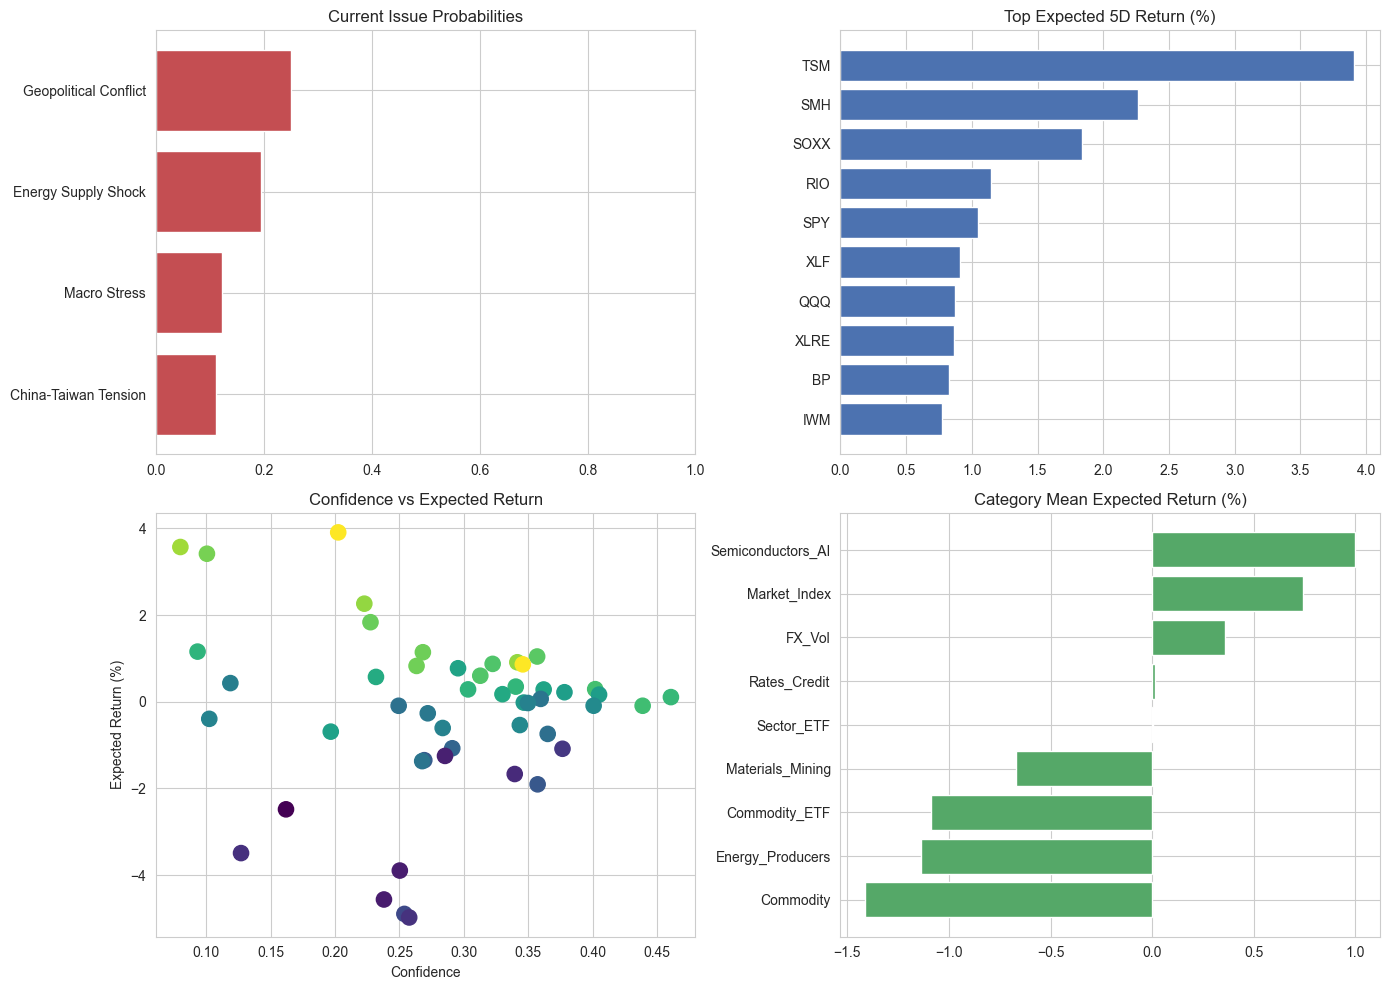

In [8]:
if len(df_predictions) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    t = df_threats.sort_values("Probability", ascending=True)
    ax.barh(t["Theme"], t["Probability"], color="#c44e52")
    ax.set_title("Current Issue Probabilities")
    ax.set_xlim(0, 1)

    ax = axes[0, 1]
    top = df_predictions.head(10).sort_values("Expected_Return_%", ascending=True)
    ax.barh(top["Stock"], top["Expected_Return_%"], color="#4c72b0")
    ax.set_title(f"Top Expected {FORECAST_HORIZON}D Return (%)")

    ax = axes[1, 0]
    ax.scatter(df_predictions["Confidence"], df_predictions["Expected_Return_%"], c=df_predictions["Up_Probability"], cmap="viridis", s=120)
    ax.set_title("Confidence vs Expected Return")
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Expected Return (%)")

    ax = axes[1, 1]
    cat = df_predictions.groupby("Category")["Expected_Return_%"].mean().sort_values()
    ax.barh(cat.index, cat.values, color="#55a868")
    ax.set_title("Category Mean Expected Return (%)")

    plt.tight_layout()
    plt.show()
else:
    print("No plot: predictions are empty.")


# 9. 최종 투자 추천

In [9]:
print("=" * 90)
print(f"Event-driven allocation view ({ANALYSIS_DATE:%Y-%m-%d}, horizon={FORECAST_HORIZON}D)")
print("=" * 90)

if len(df_predictions) == 0:
    print("Insufficient model output. Continue accumulating data and rerun.")
else:
    picks = df_predictions[df_predictions["Confidence"] >= 0.45].head(8)
    if picks.empty:
        picks = df_predictions.head(8)

    print("Top candidates:")
    print(picks[["Stock", "Category", "Expected_Return_%", "Up_Probability", "Confidence"]].to_string(index=False))
    avg_ret = picks["Expected_Return_%"].mean()
    print(f"Average expected return of picks: {avg_ret:.2f}%")

    print("\nRisk notes:")
    print("1) Model is scenario-sensitive and should be rerun frequently.")
    print("2) Use position limits and diversification.")
    print("3) Treat output as probabilistic signal, not financial advice.")


Event-driven allocation view (2026-03-10, horizon=5D)
Top candidates:
Stock     Category  Expected_Return_%  Up_Probability  Confidence
  SHY Rates_Credit           0.107641        0.629815    0.460645
Average expected return of picks: 0.11%

Risk notes:
1) Model is scenario-sensitive and should be rerun frequently.
2) Use position limits and diversification.
3) Treat output as probabilistic signal, not financial advice.


# 10. 머신러닝 기반 고급 분석

In [12]:
print("Advanced model diagnostics")
if len(df_model_eval) == 0:
    print("No diagnostics yet (not enough train rows per symbol).")
else:
    print(df_model_eval.head(12).to_string(index=False))
    print("\nModel quality distribution")

    # 새 버전 컬럼 우선
    if all(c in df_model_eval.columns for c in ["CV_MAE", "CV_R2", "CV_Up_Acc"]):
        print(df_model_eval[["CV_MAE", "CV_R2", "CV_Up_Acc", "Holdout_MAE", "Holdout_R2", "Holdout_Up_Acc"]].describe().round(3))
    # 구버전 호환
    elif all(c in df_model_eval.columns for c in ["MAE", "R2", "Up_Acc"]):
        print(df_model_eval[["MAE", "R2", "Up_Acc"]].describe().round(3))
    else:
        print("Unexpected columns in df_model_eval:")
        print(df_model_eval.columns.tolist())


Advanced model diagnostics
Stock  Rows     CV_R2   CV_MAE  CV_Up_Acc  Holdout_R2  Holdout_MAE  Holdout_Up_Acc                                                                             Best_Params
  XLE   495  0.043518 0.025633   0.596970   -1.308811     0.027222        0.515152 {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 300}
  COP   495 -0.019586 0.034773   0.533333   -1.235297     0.037450        0.464646   {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 600}
  BHP   495 -0.029375 0.030098   0.554545   -0.298704     0.038364        0.343434 {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 300}
  XOM   495 -0.034237 0.025820   0.566667   -0.652145     0.027331        0.545455 {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 600}
  DBC   495 -0.034424 0.017152   0.536364   -0.319232     0.020170        0.515152   {'max_depth': 12, 'max_features':

# 11. 종합 분석 결론

In [13]:
if len(df_predictions) > 0:
    best = df_predictions.iloc[0]
    msg = f"""
{'=' * 90}
FINAL SUMMARY
{'=' * 90}
- Current issue intensity (mean): {df_threats['Probability'].mean():.2f}
- Top forecasted asset: {best['Stock']} ({best['Category']})
- Expected {FORECAST_HORIZON}D return: {best['Expected_Return_%']:.2f}%
- Up probability: {best['Up_Probability']:.2%}
- Confidence: {best['Confidence']:.2%}

Pipeline status:
- News cache: {NEWS_CACHE_PATH}
- Price cache: {PRICE_CACHE_PATH}
- Feature rows: {len(df_features)}
- Model outputs: {len(df_predictions)}
{'=' * 90}
"""
else:
    msg = f"""
{'=' * 90}
FINAL SUMMARY
{'=' * 90}
Not enough historical rows for robust per-symbol ML training yet.
Keep collecting data daily, then rerun this notebook.
{'=' * 90}
"""

print(msg)


NameError: name 'NEWS_CACHE_PATH' is not defined

# 12. 데이터 커버리지 점검

In [ ]:
print("Data coverage report")
print("=" * 90)

if 'df_news' in globals() and isinstance(df_news, pd.DataFrame) and len(df_news) > 0:
    news_dates = pd.to_datetime(df_news['date'], utc=True, errors='coerce').dropna()
    print("[News]")
    print(f"Rows: {len(df_news):,}")
    print(f"Date range: {news_dates.min()} -> {news_dates.max()}")
    print(f"Unique sources: {df_news['source'].nunique() if 'source' in df_news.columns else 0}")
else:
    print("[News]")
    print("No news data available.")

print("\n" + "-" * 90)

if 'df_prices' in globals() and isinstance(df_prices, pd.DataFrame) and len(df_prices) > 0:
    ptmp = df_prices.copy()
    ptmp['date'] = pd.to_datetime(ptmp['date'], utc=True, errors='coerce')
    ptmp = ptmp.dropna(subset=['date'])

    summary = (
        ptmp.groupby(['symbol', 'category'], as_index=False)
        .agg(
            rows=('date', 'count'),
            first_date=('date', 'min'),
            last_date=('date', 'max'),
            last_close=('close', 'last')
        )
        .sort_values(['category', 'symbol'])
        .reset_index(drop=True)
    )
    summary['calendar_days'] = (summary['last_date'] - summary['first_date']).dt.days

    print("[Prices by symbol]")
    print(f"Total rows: {len(ptmp):,}")
    print(f"Tracked symbols: {summary['symbol'].nunique()}")
    print(f"Overall date range: {ptmp['date'].min()} -> {ptmp['date'].max()}")

    print("\nCoverage table (head 30):")
    print(summary[['symbol', 'category', 'rows', 'first_date', 'last_date', 'calendar_days', 'last_close']].head(30).to_string(index=False))

    print("\nCoverage stats:")
    print(summary['rows'].describe().round(1).to_string())

    low_cov = summary[summary['rows'] < 200]
    if len(low_cov) > 0:
        print("\nSymbols with low coverage (<200 rows):")
        print(low_cov[['symbol', 'category', 'rows', 'first_date', 'last_date']].to_string(index=False))
else:
    print("[Prices]")
    print("No price data available.")

print("=" * 90)


Data coverage report
[News]
Rows: 323
Date range: 2026-02-10 15:59:00+00:00 -> 2026-03-09 01:29:39+00:00
Unique sources: 133

------------------------------------------------------------------------------------------
[Prices by symbol]
Total rows: 24,512
Tracked symbols: 49
Overall date range: 2024-03-11 00:00:00+00:00 -> 2026-03-09 00:00:00+00:00

Coverage table (head 30):
symbol         category  rows                first_date                 last_date  calendar_days  last_close
  BZ=F        Commodity   502 2024-03-11 00:00:00+00:00 2026-03-09 00:00:00+00:00            728  101.820000
  CL=F        Commodity   502 2024-03-11 00:00:00+00:00 2026-03-09 00:00:00+00:00            728   99.510002
  GC=F        Commodity   502 2024-03-11 00:00:00+00:00 2026-03-09 00:00:00+00:00            728 5085.500000
  HG=F        Commodity   502 2024-03-11 00:00:00+00:00 2026-03-09 00:00:00+00:00            728    5.774500
  NG=F        Commodity   502 2024-03-11 00:00:00+00:00 2026-03-09 00:00:00+00